# 03 - Emergency Department Capacity Planning

**CVD Risk Stratification & ED Capacity Planning project**

This notebook demonstrates the Emergency Department (ED) capacity-planning module.
It forecasts ED demand by cardiovascular (CVD) risk group, converts the forecast
into concrete resource requirements, optimises staffing cost, and visualises the
results.

**Pipeline stages**
1. **Demand forecasting** - Prophet + SARIMA ensemble, per risk group (60-day horizon).
2. **Resource allocation** - risk-stratified bed / staff / equipment / lab rules
   with a 20% surge buffer and HIGH_DEMAND alerts.
3. **Optimisation** - linear programming (PuLP/CBC) for cost-minimised staffing.
4. **Dashboard** - 8 figures + an HTML summary dashboard.

> Methodology recap: High-risk patients (intensity 3) need ICU beds, cardiology,
> echo and troponin; Medium risk (2) need monitored beds, ECG and basic labs;
> Low risk (1) need a standard ED bay and triage.


In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, HTML, display

# Ensure the project root is importable.
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.ed_capacity import (
    DemandForecaster, ResourceAllocator, CapacityOptimizer, CapacityDashboard,
)
from src.ed_capacity import common

pd.set_option("display.max_columns", 40)
FIG = common.FIGURES_DIR
REP = common.REPORTS_DIR
print("Project root:", common.PROJECT_ROOT)

Project root: /home/ubuntu/github_repos/Data-Analytic-Data-Engineering


## 1. Load the daily ED demand history

Daily ED visit counts by CVD risk group come from the feature store, with risk labels assigned via the trained `RiskStratifier`.

In [2]:
history = common.wide_demand()
print("History:", history.index.min().date(), "->", history.index.max().date(),
      f"({len(history)} days)")
history.tail()

History: 2024-09-11 -> 2026-08-31 (720 days)


risk_level,Low,Medium,High,Total
visit_date,,,,
2026-08-27,4.0,6.0,4.0,14.0
2026-08-28,5.0,5.0,6.0,16.0
2026-08-29,4.0,0.0,5.0,9.0
2026-08-30,7.0,4.0,4.0,15.0
2026-08-31,4.0,1.0,4.0,9.0


In [3]:
ax = history[common.RISK_ORDER].rolling(14).mean().plot(
    figsize=(12,5), color=[common.RISK_COLORS[g] for g in common.RISK_ORDER])
ax.set_title("Historical daily ED demand by risk group (14-day rolling mean)")
ax.set_ylabel("Daily ED visits"); ax.set_xlabel("Date")
plt.show()

## 2. Demand forecasting (Prophet + SARIMA ensemble)

We train on the trailing 22 months and forecast the next 60 days for each risk group. Each group's forecast is a weighted ensemble (60% Prophet / 40% SARIMA).

In [4]:
forecaster = DemandForecaster()
forecaster.load_data()
forecast = forecaster.forecast_all()
forecaster.save_forecast(forecast)
forecaster.plot_forecasts()
forecast.groupby("risk_level")["forecast"].describe().round(2)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


05:30:49 - cmdstanpy - INFO - Chain [1] start processing


05:30:49 - cmdstanpy - INFO - Chain [1] done processing


Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


05:30:49 - cmdstanpy - INFO - Chain [1] start processing


05:30:49 - cmdstanpy - INFO - Chain [1] done processing


Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


05:30:50 - cmdstanpy - INFO - Chain [1] start processing


05:30:50 - cmdstanpy - INFO - Chain [1] done processing


,count,mean,std,min,25%,50%,75%,max
risk_level,,,,,,,,
High,60.0,4.61,0.63,3.60,4.04,4.65,5.05,6.10
Low,60.0,4.42,0.61,3.36,3.98,4.25,4.89,5.67
Medium,60.0,3.88,0.48,2.80,3.55,3.94,4.19,4.81


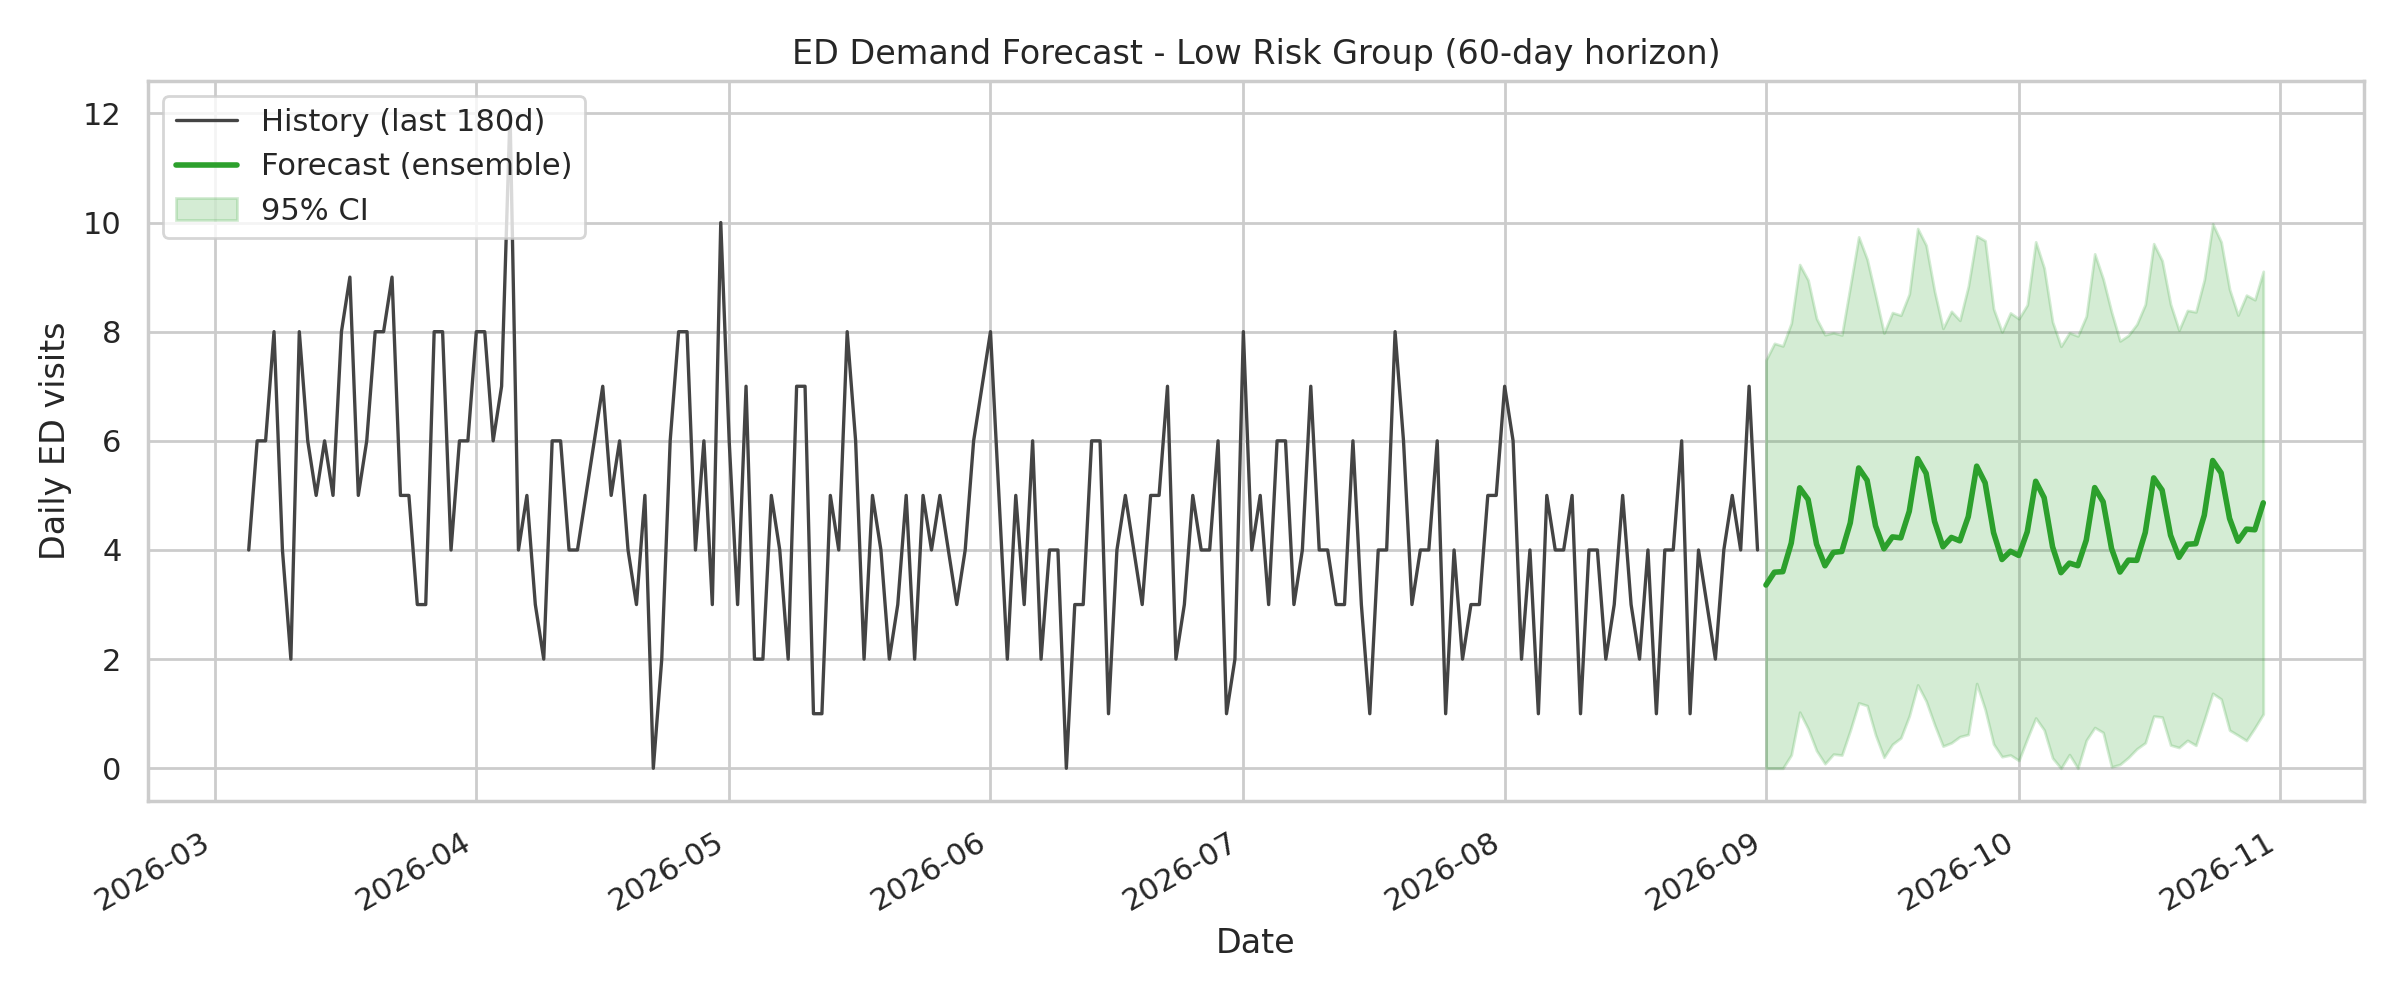

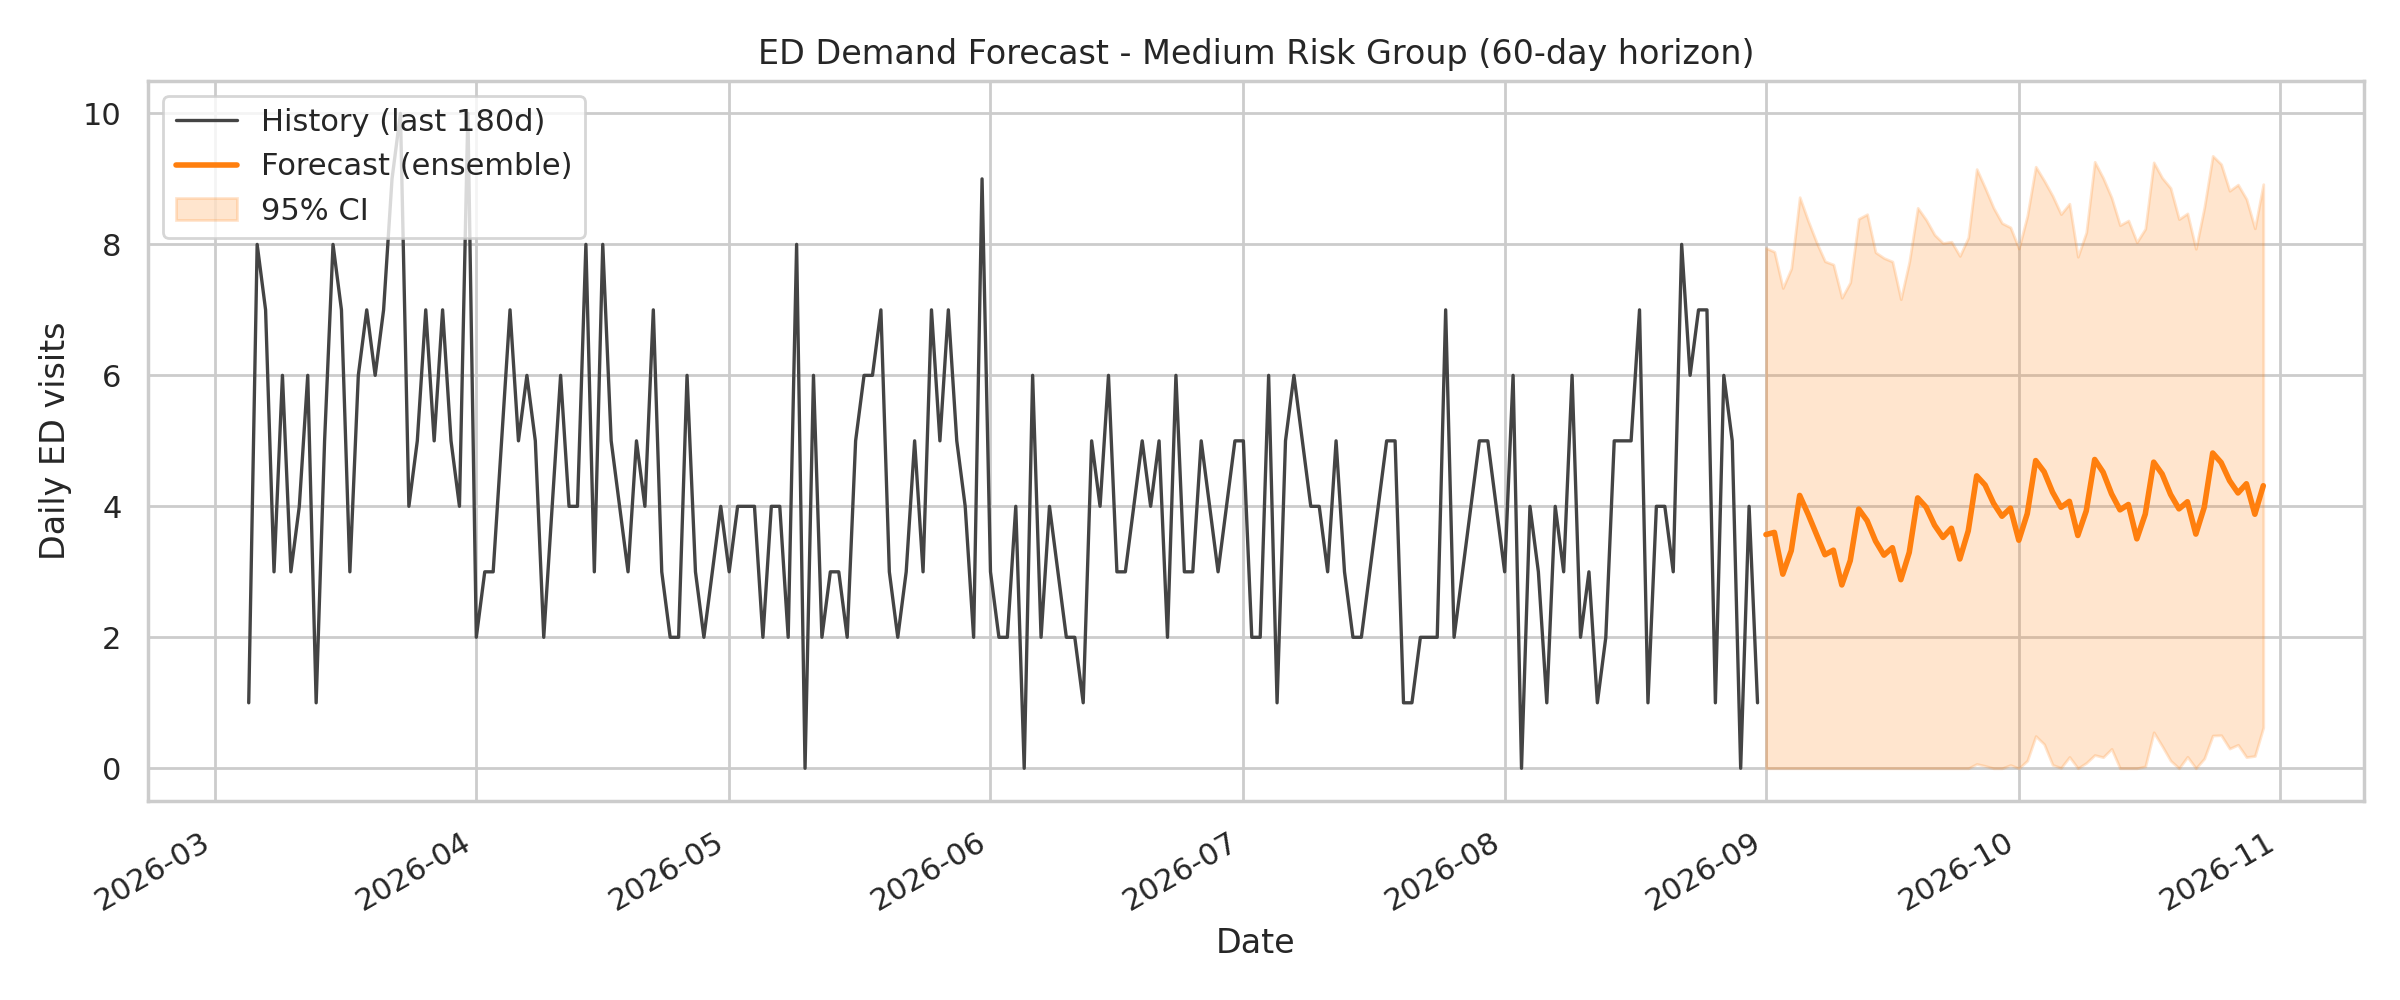

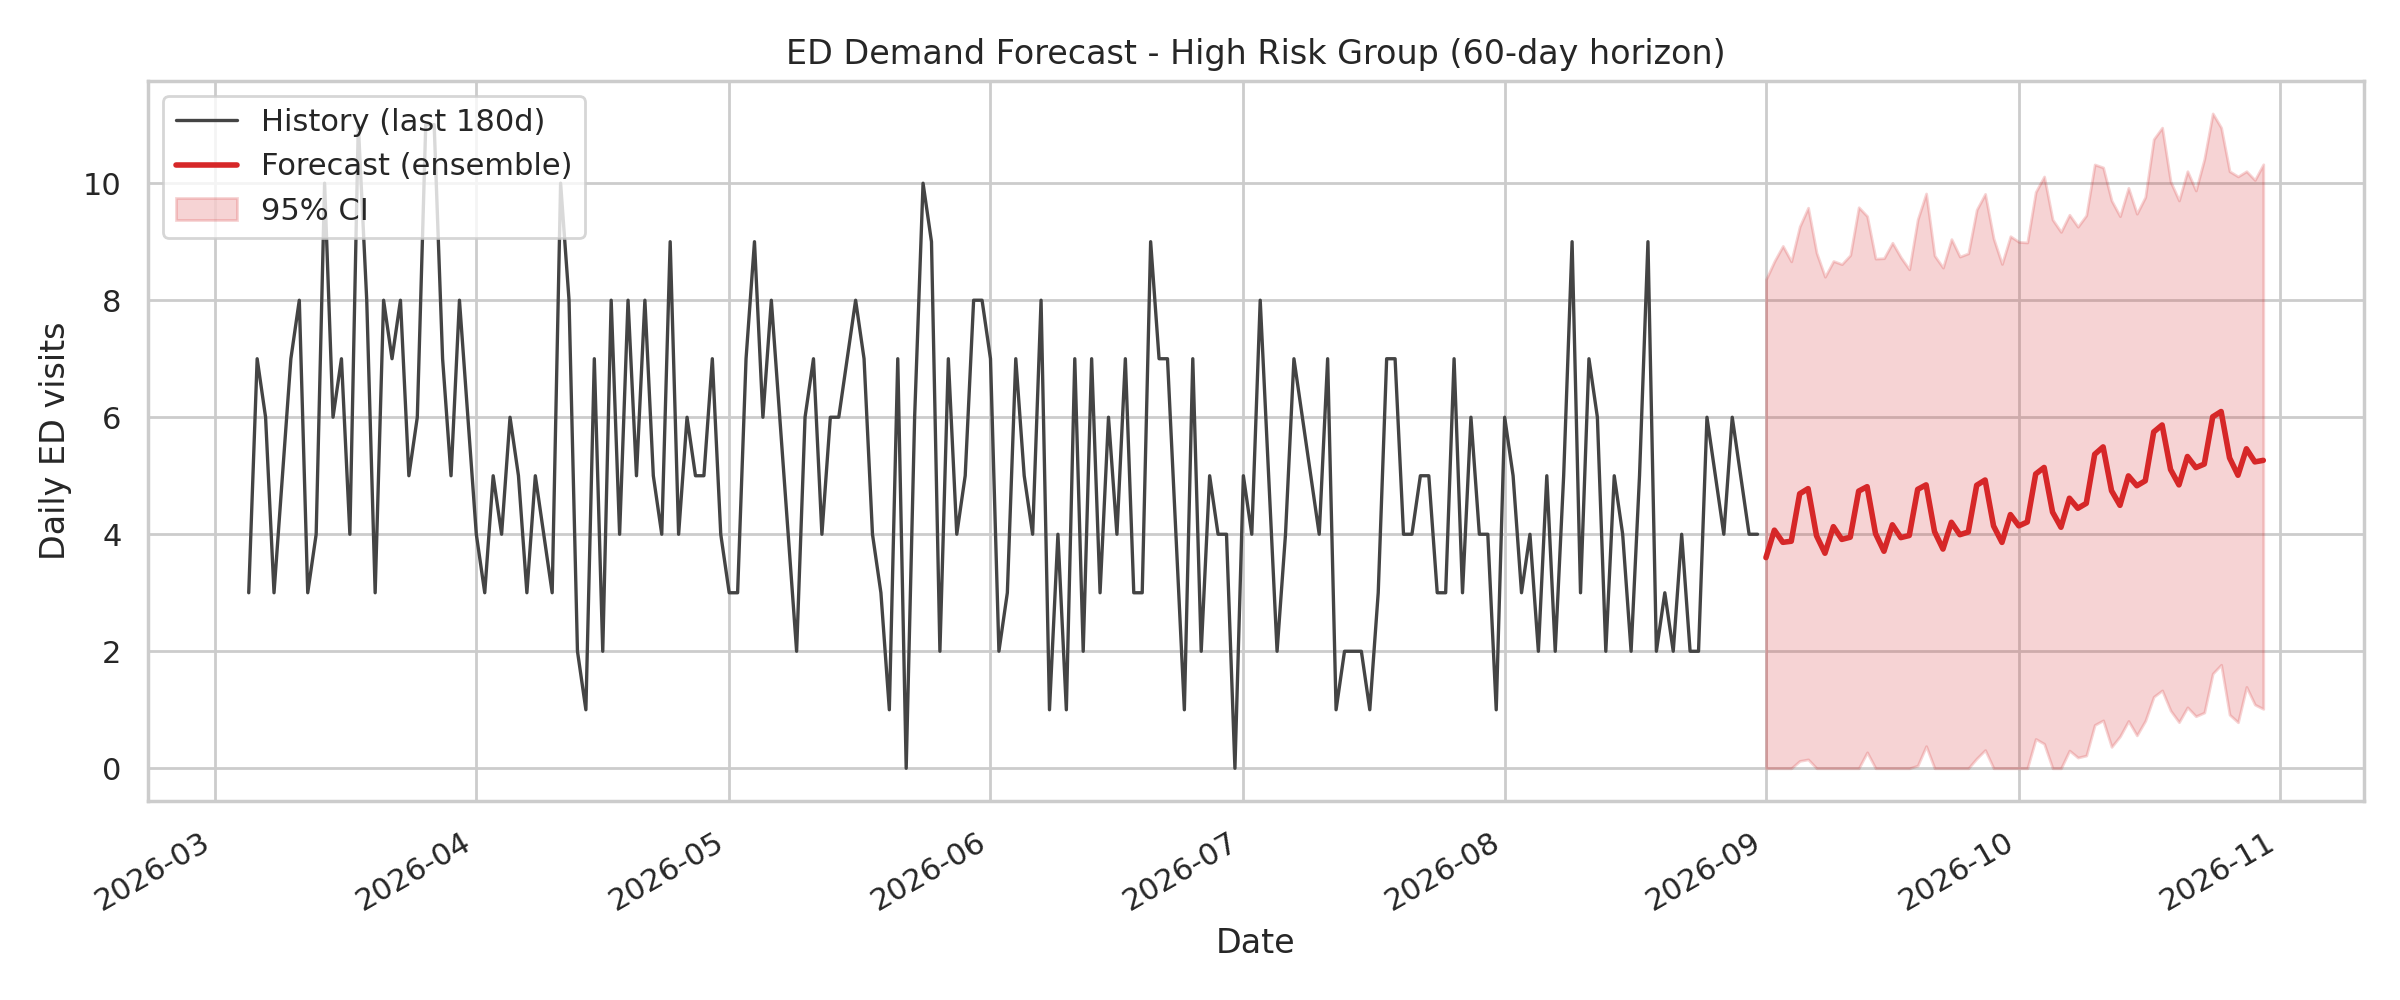

In [5]:
for g in common.RISK_ORDER:
    p = os.path.join(FIG, f"ed_demand_forecast_{g.lower()}.png")
    if os.path.exists(p):
        display(Image(filename=p))

## 3. Resource allocation

The forecast is converted into daily bed, staff, equipment and lab requirements. A **20% surge buffer** is applied to every estimate, and days above **85% capacity utilisation** are flagged `HIGH_DEMAND`.

In [6]:
allocator = ResourceAllocator()
plan = allocator.run(forecast)
summary = allocator.summary(plan)
summary

{'days': 60,
 'high_demand_days': 3,
 'peak_total_beds': 13,
 'peak_icu_beds': 8,
 'peak_physicians': 4,
 'peak_nurses': 8,
 'mean_utilization': 0.6914999999999999,
 'peak_utilization': 0.889,
 'total_forecast_visits': 774.6}

In [7]:
plan[[
    "demand_total","icu_beds_needed","monitored_beds_needed","standard_beds_needed",
    "total_beds_needed","physicians_needed","nurses_needed","techs_needed",
    "capacity_utilization","alert",
]].head(10)

,demand_total,icu_beds_needed,monitored_beds_needed,standard_beds_needed,total_beds_needed,physicians_needed,nurses_needed,techs_needed,capacity_utilization,alert
date,,,,,,,,,,
2026-09-01,10.5,5,3,2,10,3,6,1,0.6,NORMAL
2026-09-02,11.3,5,3,2,10,3,6,1,0.6,NORMAL
2026-09-03,10.4,5,2,2,9,3,6,1,0.6,NORMAL
2026-09-04,11.3,5,2,2,9,3,6,1,0.6,NORMAL
2026-09-05,14.0,6,3,2,11,3,7,2,0.7,NORMAL
2026-09-06,13.6,6,3,2,11,3,7,2,0.7,NORMAL
2026-09-07,11.7,5,3,2,10,3,6,1,0.6,NORMAL
2026-09-08,10.6,5,2,2,9,3,6,1,0.6,NORMAL
2026-09-09,11.4,5,2,2,9,3,6,1,0.6,NORMAL


In [8]:
high = plan[plan["alert"] == "HIGH_DEMAND"]
print(f"HIGH_DEMAND days: {len(high)} of {len(plan)}")
high[["demand_total","total_beds_needed","icu_beds_needed",
      "physicians_needed","nurses_needed","capacity_utilization"]]

HIGH_DEMAND days: 3 of 60


,demand_total,total_beds_needed,icu_beds_needed,physicians_needed,nurses_needed,capacity_utilization
date,,,,,,
2026-10-18,15.5,13,8,4,8,0.889
2026-10-24,16.5,13,8,4,8,0.889
2026-10-25,16.2,13,8,4,8,0.889


## 4. Capacity optimisation (linear programming)

A linear program minimises daily staffing cost subject to demand-coverage, minimum-staffing, and surge-capacity constraints, over a rolling 7-day horizon.

In [9]:
optimizer = CapacityOptimizer()
schedule = optimizer.run(plan, rolling_days=7)
print(f"Total optimised weekly staffing cost: ${schedule['daily_cost'].sum():,.0f}")
schedule

Total optimised weekly staffing cost: $127,400


,day_of_week,demand_total,physicians_required,physicians_scheduled,nurses_required,nurses_scheduled,techs_required,techs_scheduled,daily_cost,coverage_ok,solver_status
date,,,,,,,,,,,
2026-09-01,Tuesday,10.5,3,3,6,8,1,2,18200.0,True,Optimal
2026-09-02,Wednesday,11.3,3,3,6,8,1,2,18200.0,True,Optimal
2026-09-03,Thursday,10.4,3,3,6,8,1,2,18200.0,True,Optimal
2026-09-04,Friday,11.3,3,3,6,8,1,2,18200.0,True,Optimal
2026-09-05,Saturday,14.0,3,3,7,8,2,2,18200.0,True,Optimal
2026-09-06,Sunday,13.6,3,3,7,8,2,2,18200.0,True,Optimal
2026-09-07,Monday,11.7,3,3,6,8,1,2,18200.0,True,Optimal


## 5. Capacity dashboard (8 visualisations)

Generate the full figure set and the HTML dashboard, then display each figure inline.

HTML dashboard: /home/ubuntu/github_repos/Data-Analytic-Data-Engineering/outputs/reports/capacity_dashboard.html


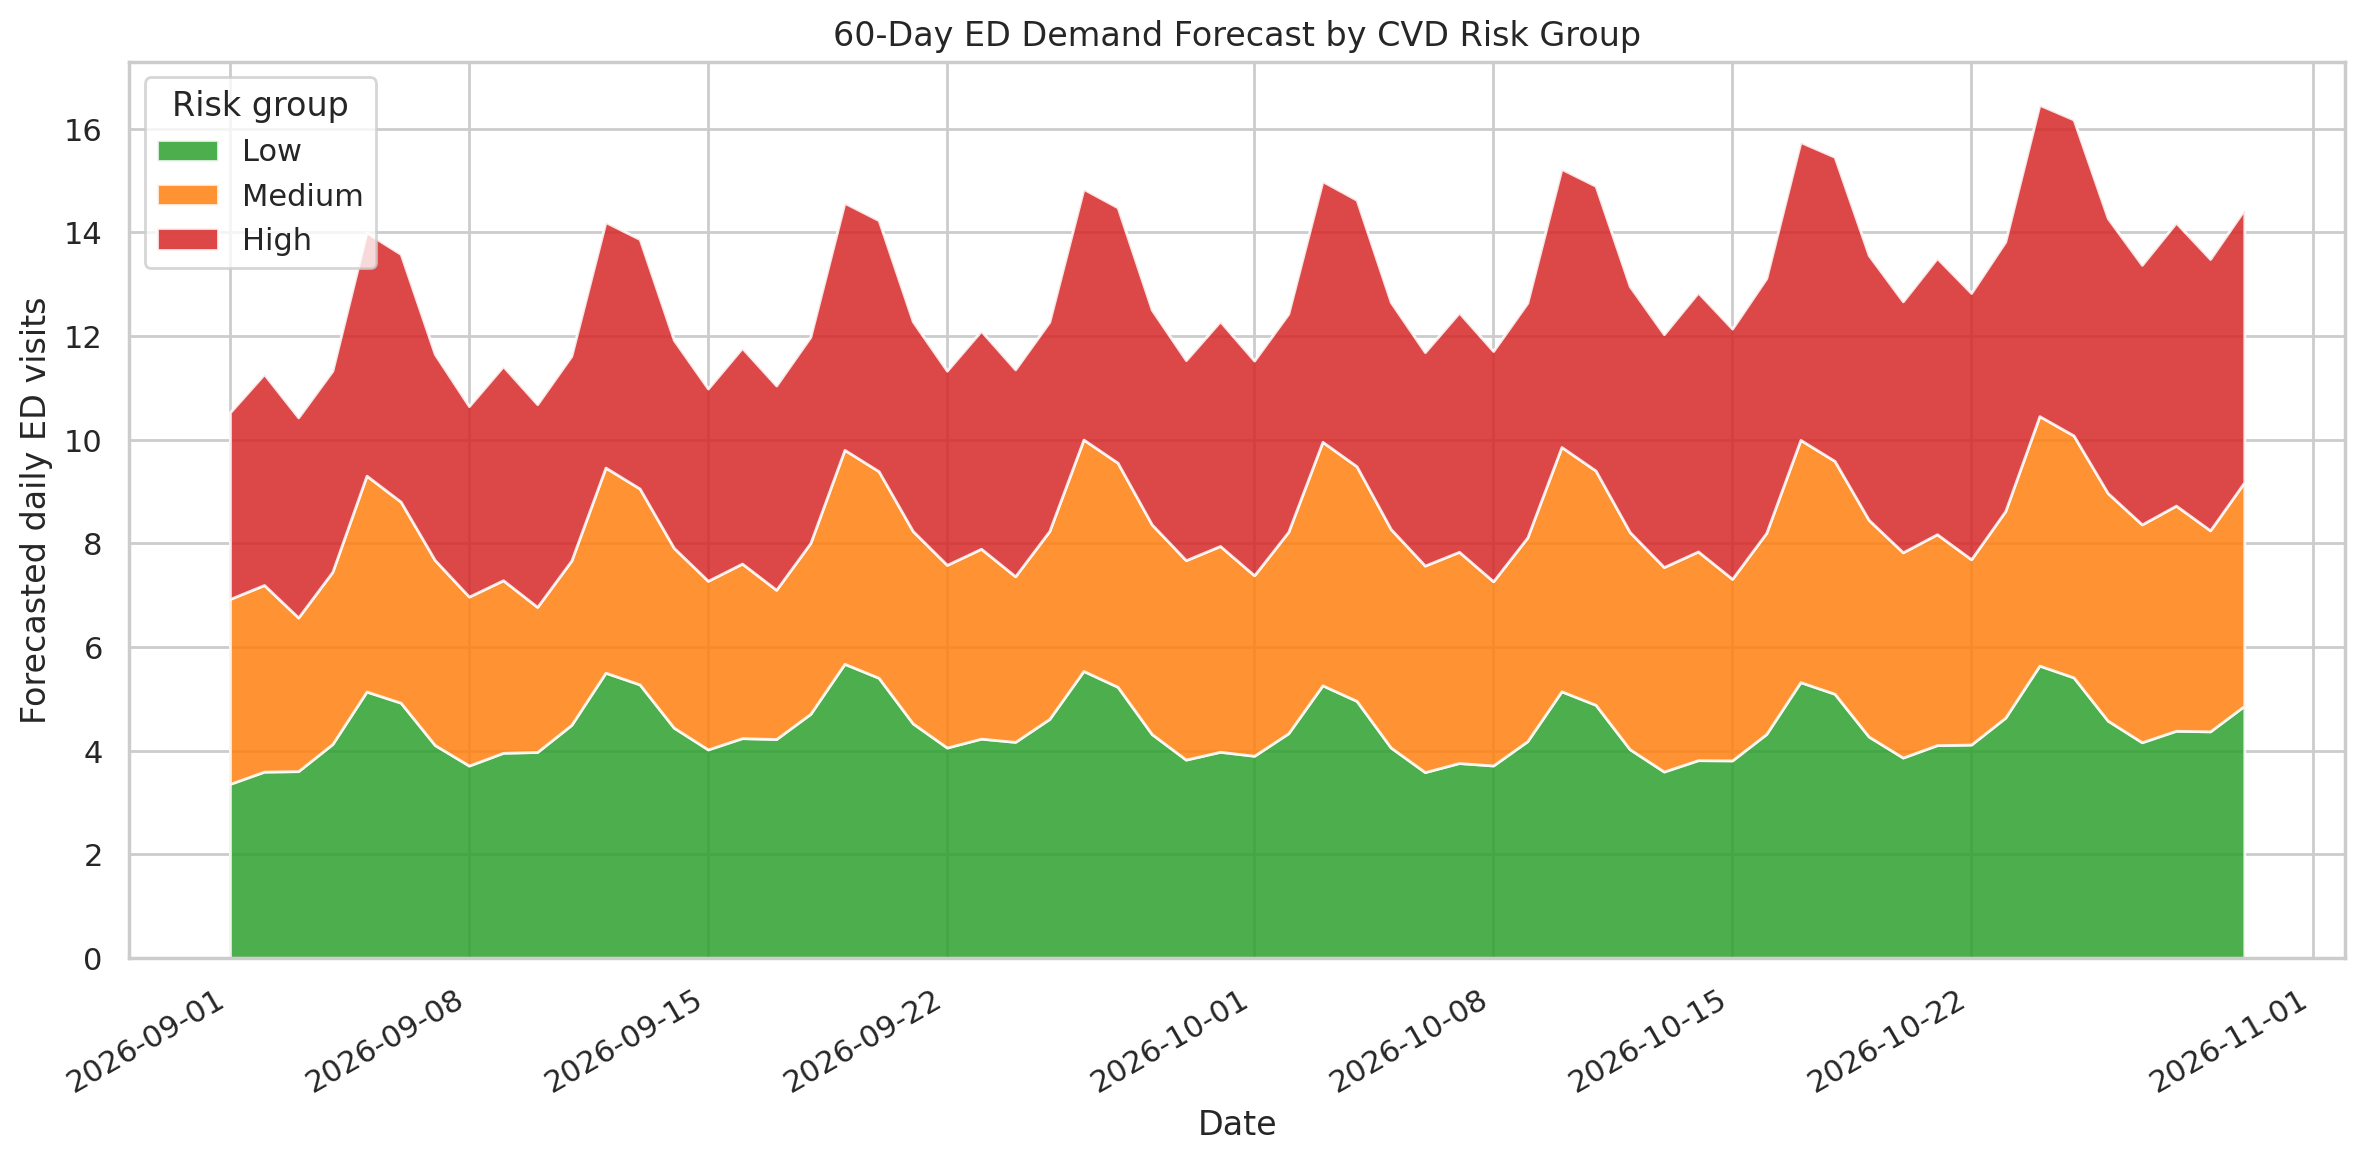

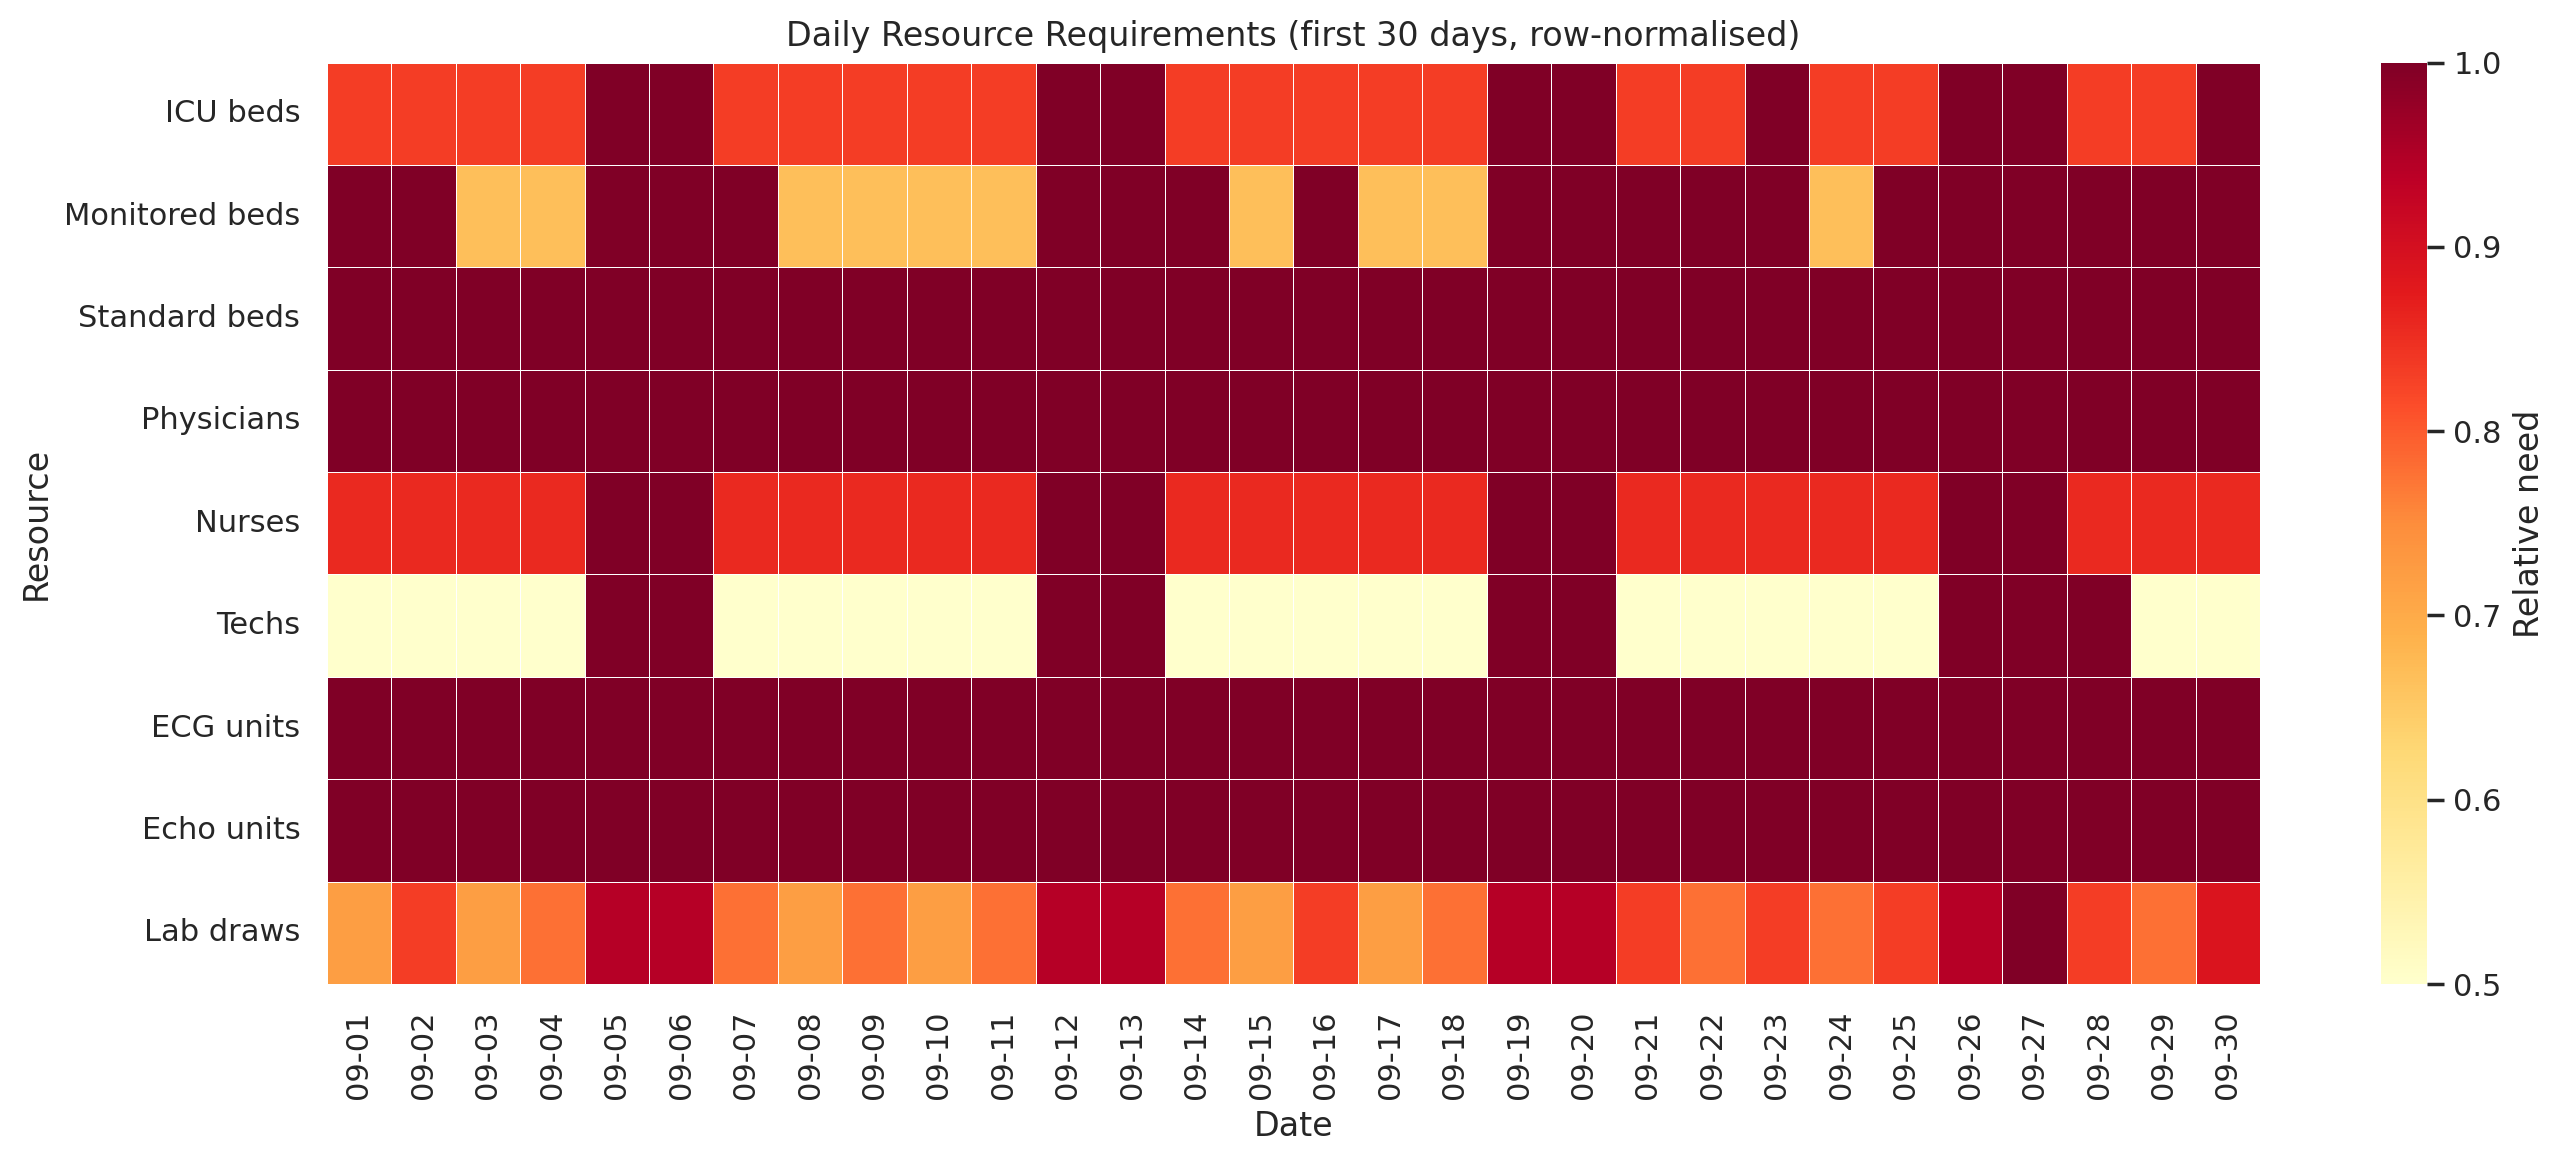

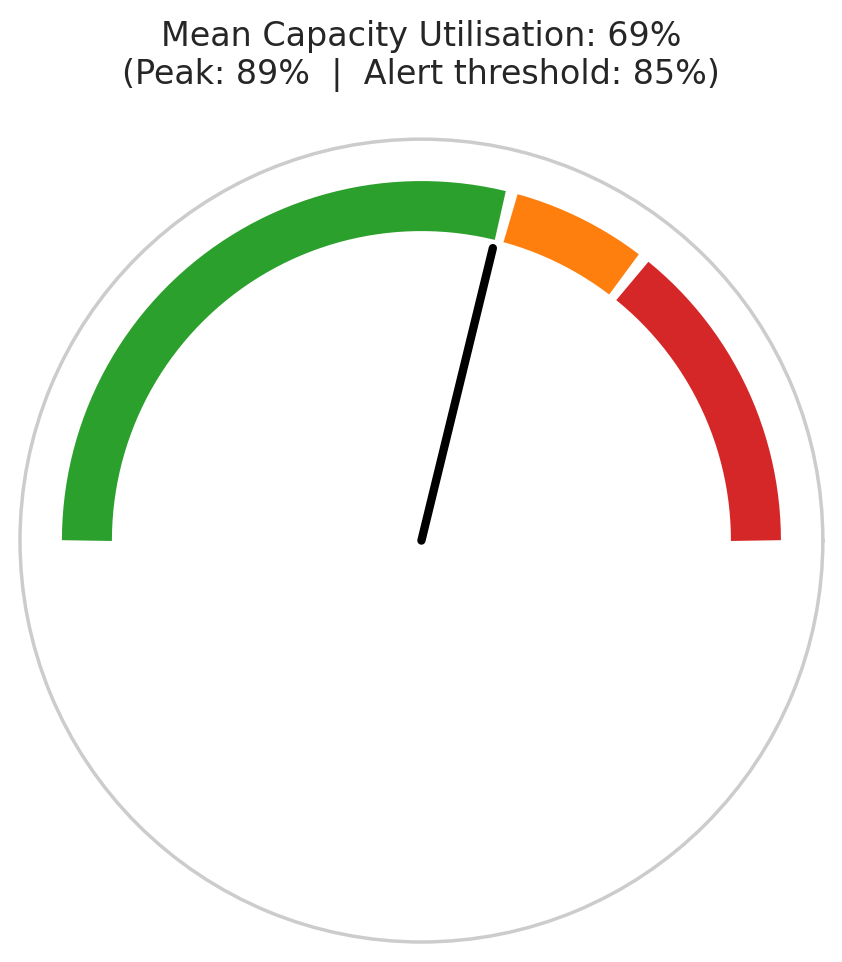

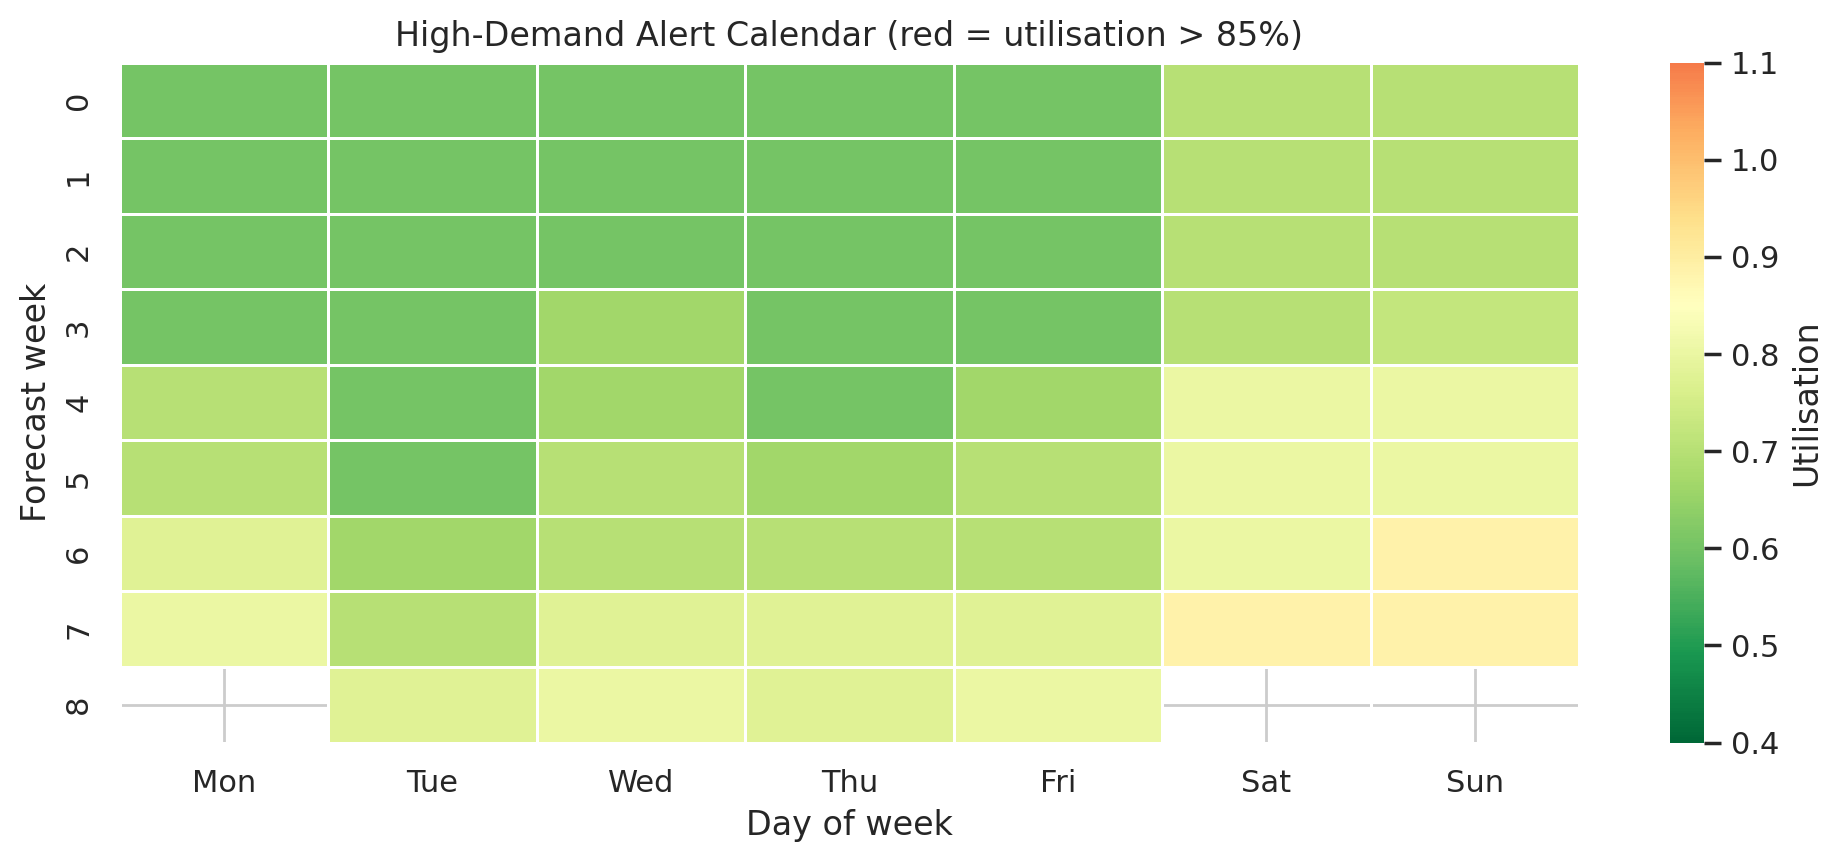

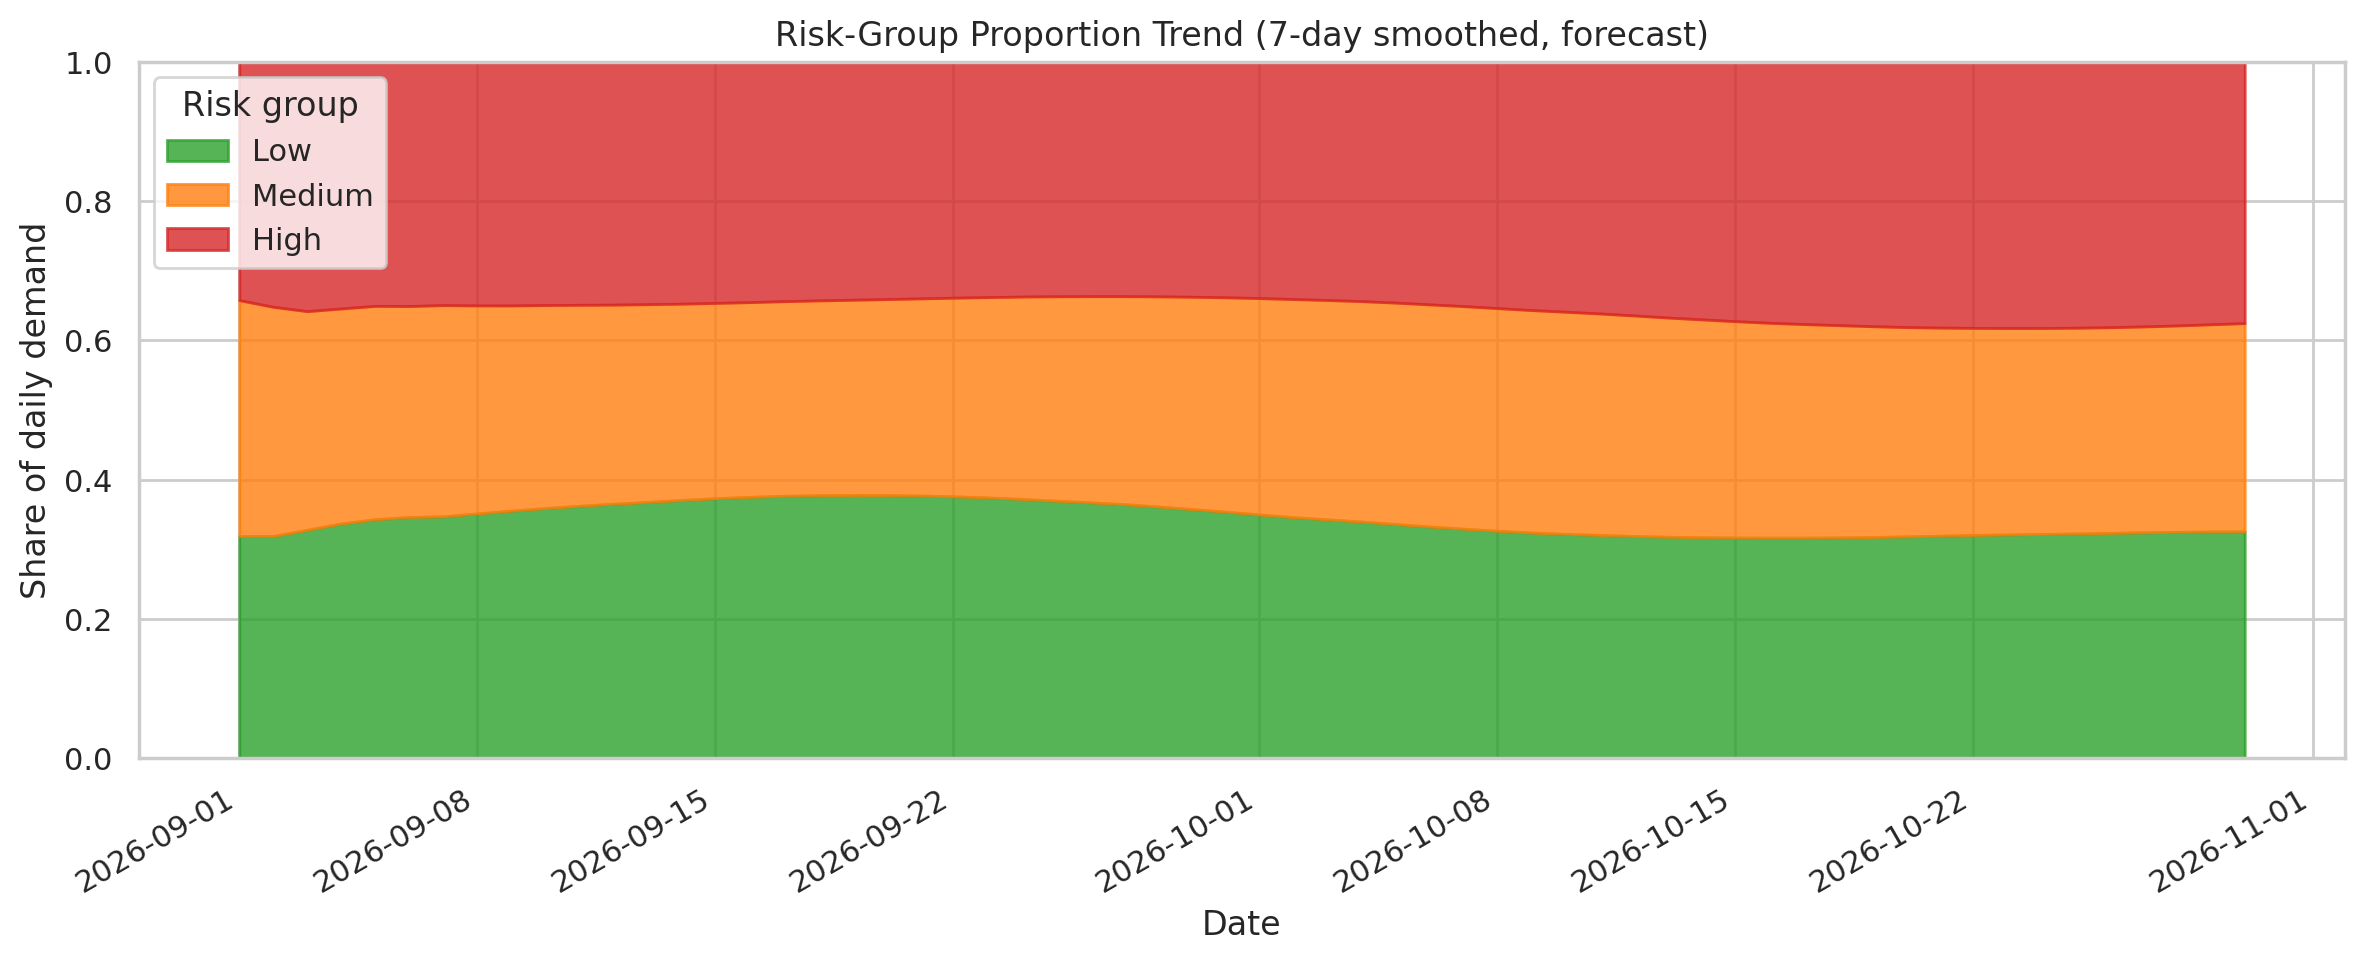

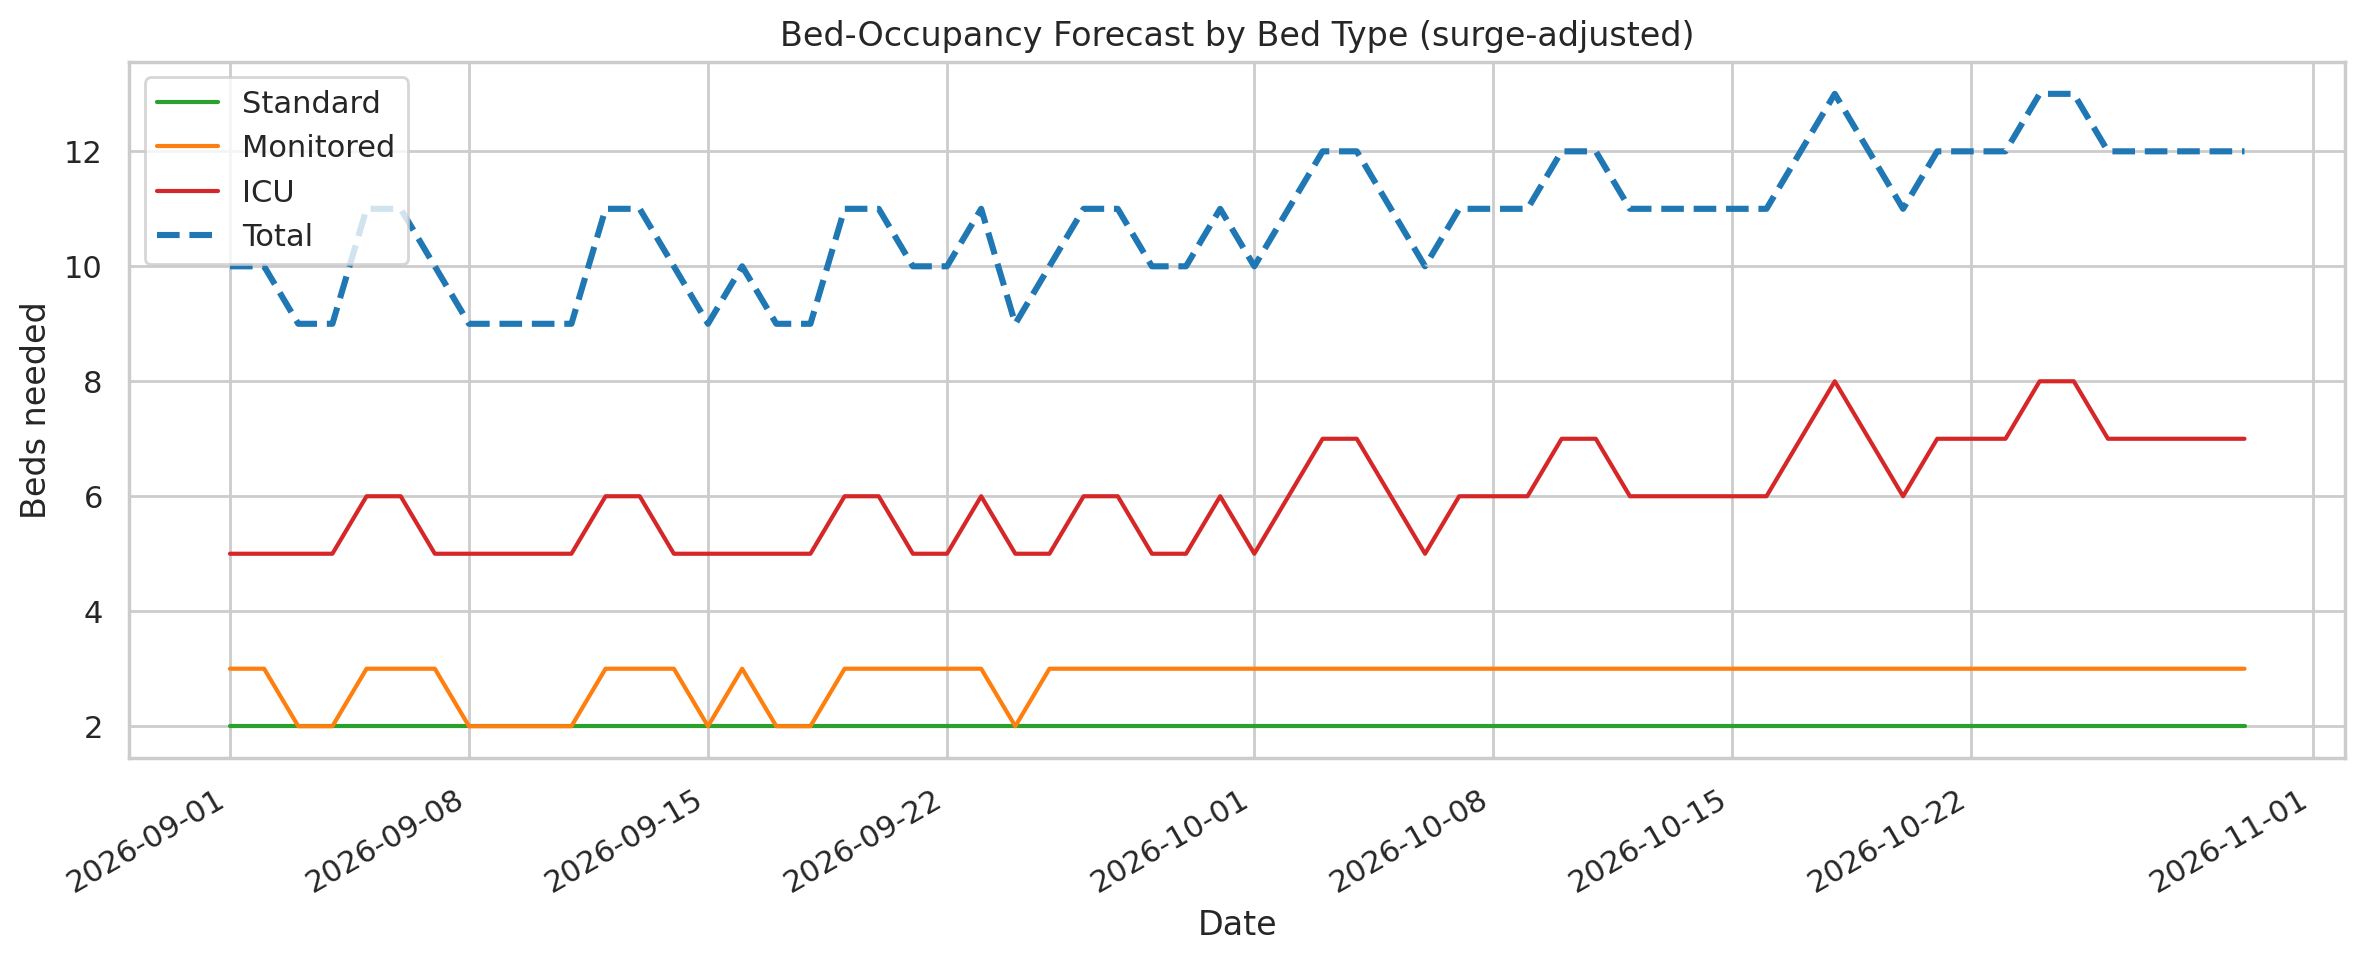

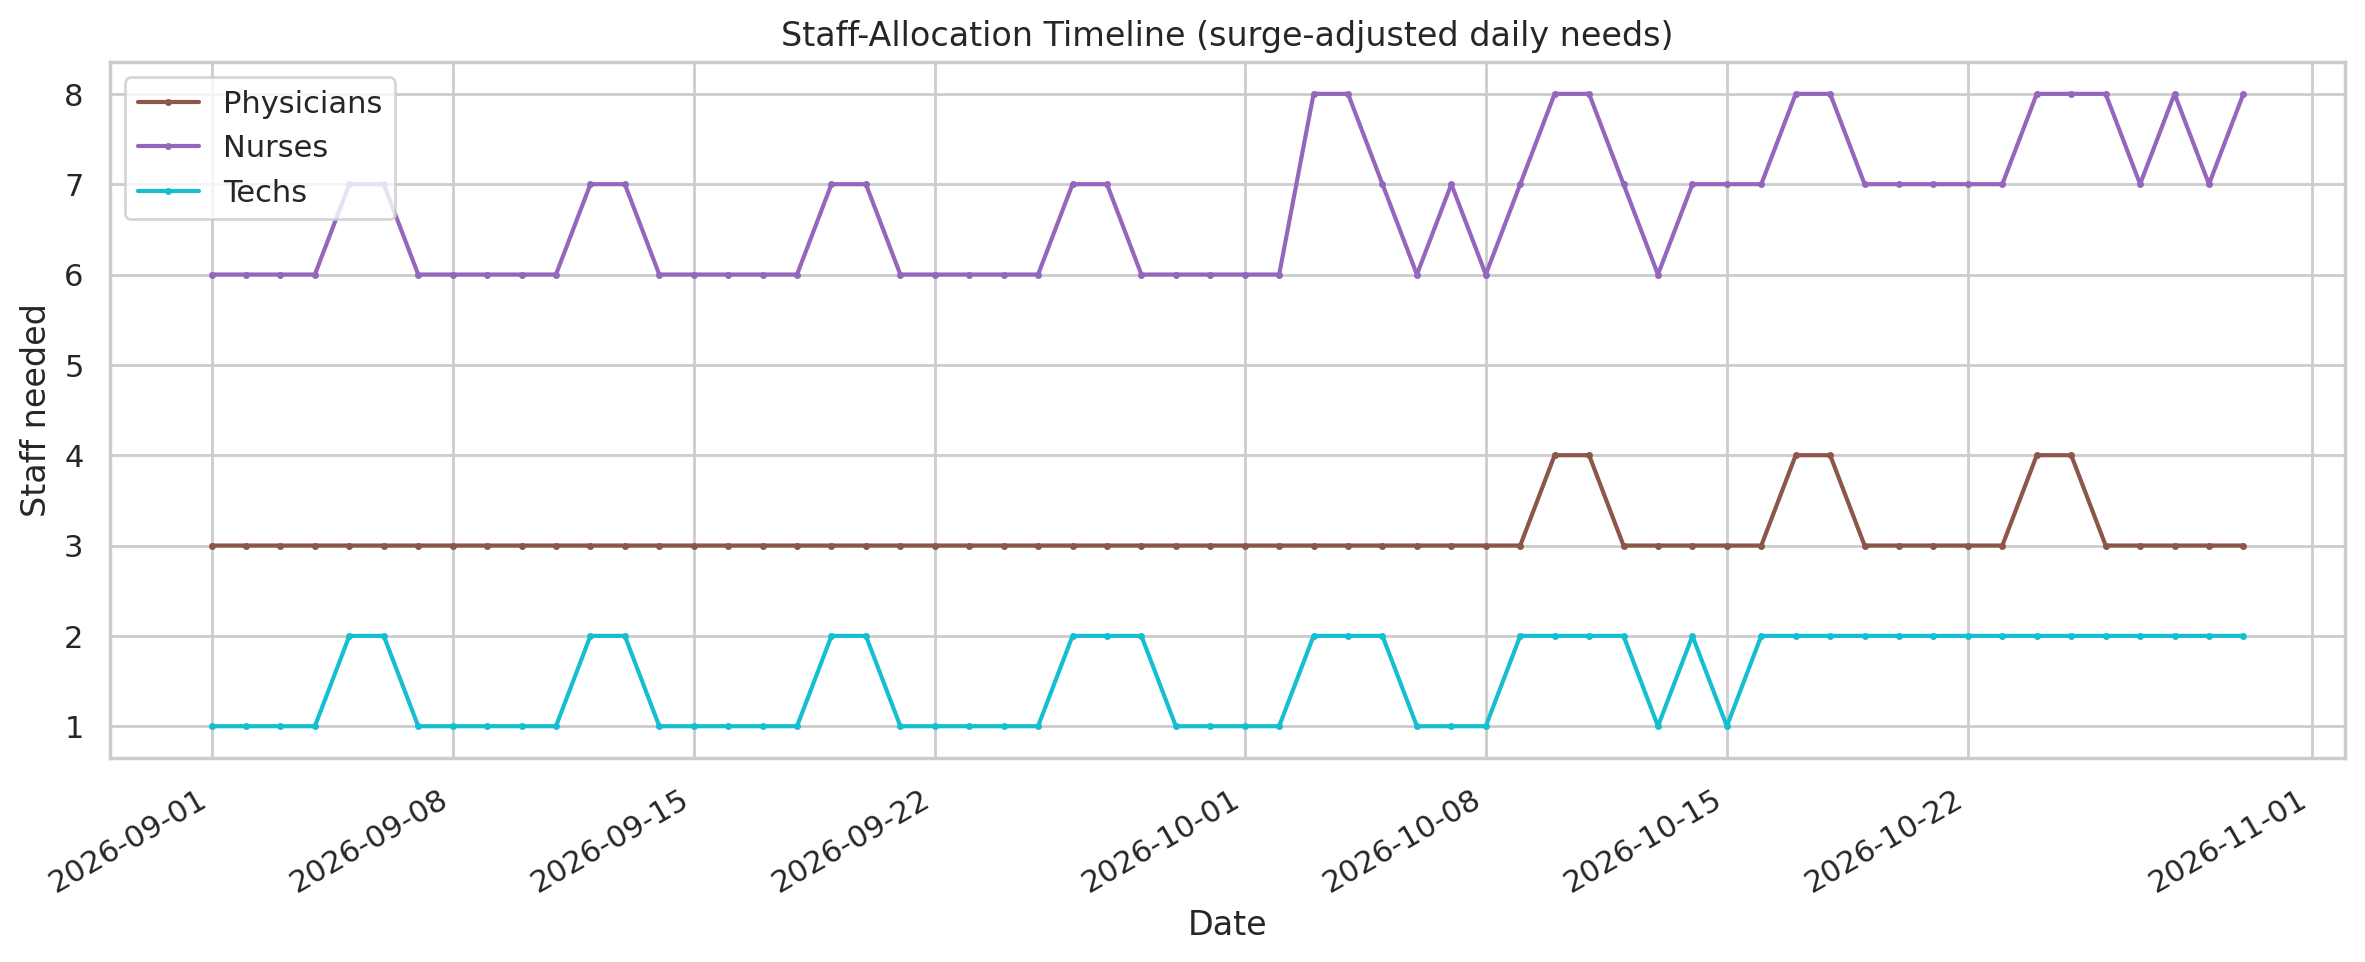

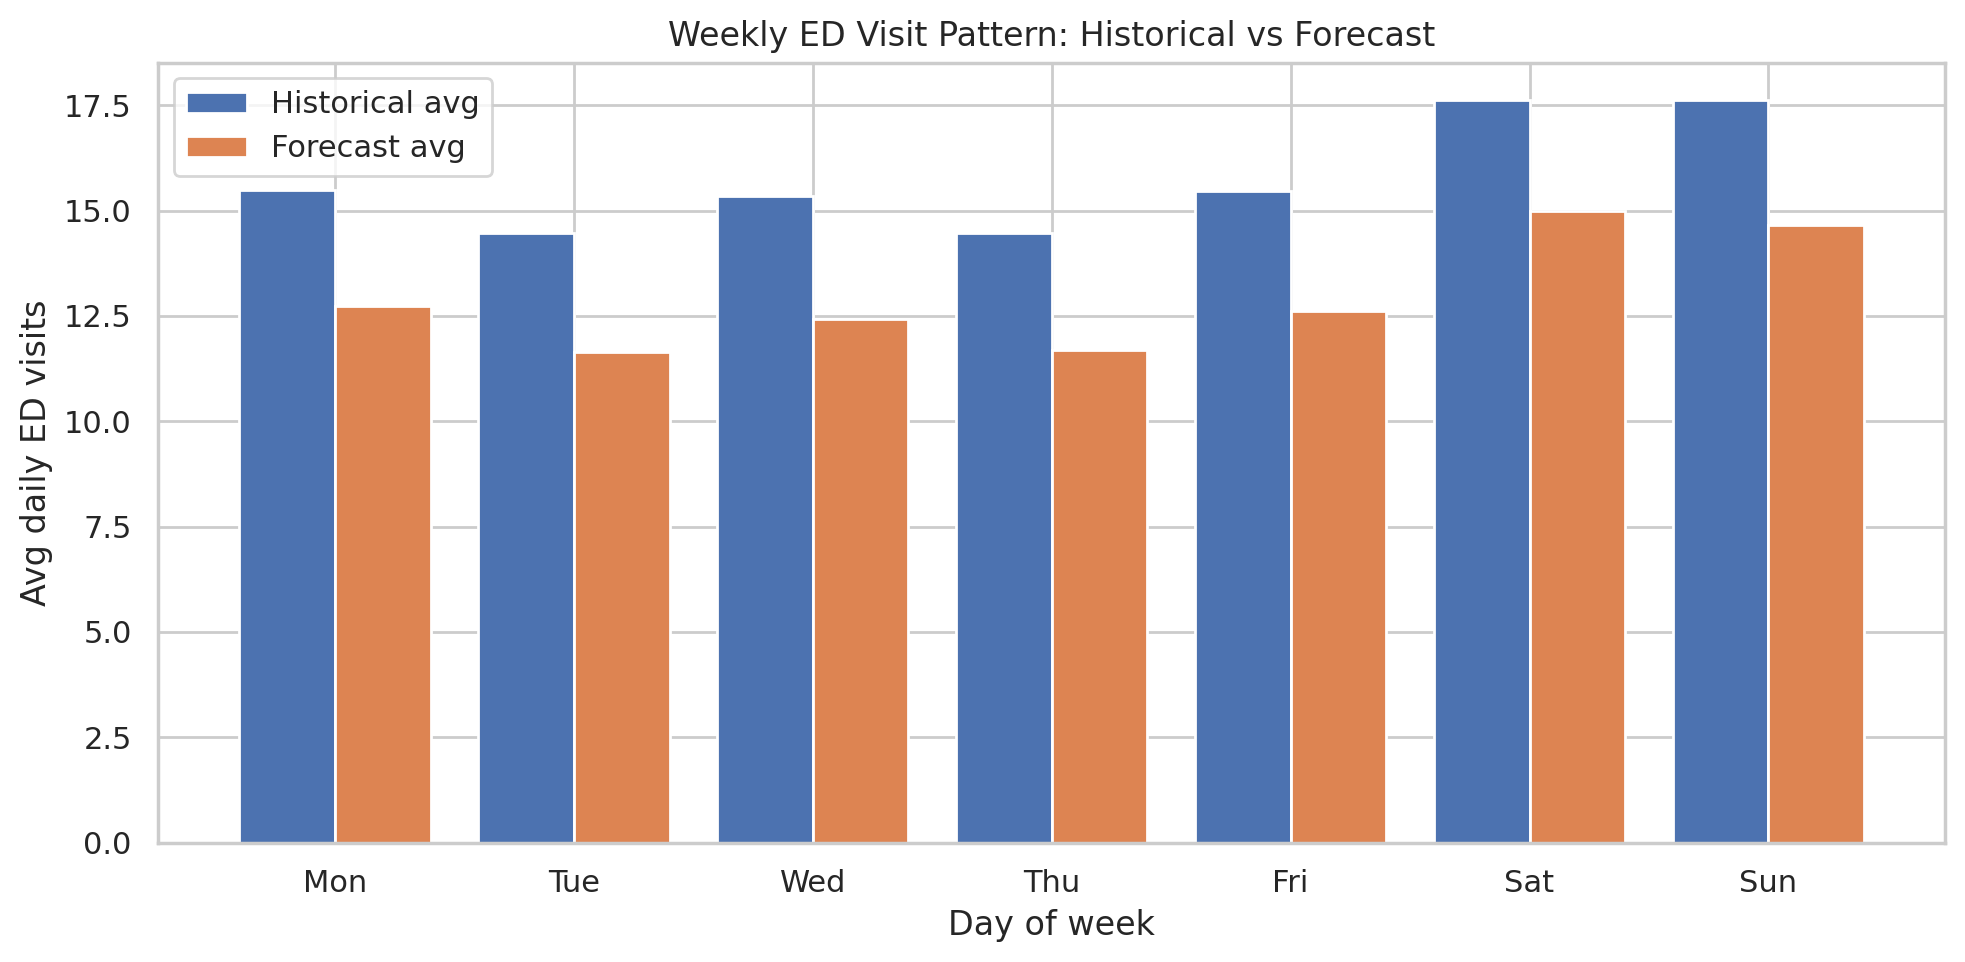

In [10]:
dashboard = CapacityDashboard(forecast, plan, history=history, summary=summary)
figs = dashboard.build_all_figures()
html_path = dashboard.build_html()
print("HTML dashboard:", html_path)
for name in sorted(figs):
    display(Image(filename=figs[name]))

## 6. ED capacity report

The orchestrator also writes a Markdown summary report. Below we render its contents inline.

In [11]:
report_path = os.path.join(REP, "ed_capacity_report.md")
if os.path.exists(report_path):
    with open(report_path) as fh:
        display(HTML("<div style='max-height:500px;overflow:auto;border:1px solid "
                     "#ddd;padding:12px'>" + fh.read().replace(chr(10), "<br>") + "</div>"))

## 7. Summary & methodology notes

- **Forecasting:** an ensemble of Prophet (weekly/yearly seasonality, 95% CIs) and
  SARIMA `(1,1,1)(1,1,1)_7` produces a 60-day per-risk-group demand forecast.
  SARIMA is also the automatic fallback if Prophet is unavailable.
- **Allocation:** risk-stratified rules map demand to ICU / monitored / standard
  beds, physician / nurse / tech staffing, ECG / echo equipment, and lab draws,
  all with a 20% surge buffer. Capacity utilisation > 85% triggers HIGH_DEMAND
  alerts.
- **Optimisation:** a PuLP/CBC linear program yields the minimum-cost 7-day
  staffing schedule that still satisfies coverage and safety floors.
- **Outputs:** CSVs (`ed_demand_forecast.csv`, `resource_allocation_plan.csv`,
  `capacity_optimization.csv`), figures (`outputs/figures/ed_capacity_*.png`), an
  HTML dashboard, and a Markdown report - all under `outputs/`.

Run the whole thing end-to-end with:

```bash
python -m src.ed_capacity.ed_pipeline
```
